# IPCV Assignment — Emotion Detection in Social Media Images

# By Chinelo Lydia Nweke

## Data Source
###  Download FER2013 from Kaggle:
###    https://www.kaggle.com/datasets/msambare/fer2013

## Dataset Loading & Exploration

### Loading Libraries

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

### 1. CONFIGURATION

In [2]:
DATA_DIR = Path("data")
TRAIN_DIR = DATA_DIR / "train"
TEST_DIR  = DATA_DIR / "test"

In [3]:
from pathlib import Path

downloads = Path.home() / "Downloads"
candidates = []
for p in downloads.rglob("*"):
    if p.is_dir():
        if (p / "train").is_dir() and (p / "test").is_dir():
            candidates.append(p)

print("Downloads:", downloads)
if candidates:
    print("\nFound candidate folders (set SRC_ROOT to one of these):")
    for c in sorted(set(candidates)):
        print(" -", c)
else:
    print("\nNo candidate archive folder found under Downloads.")
    print("You can:")
    print(" - Move the downloaded archive to Downloads and unzip it, or")
    print(" - Copy the folder path and paste it into SRC_ROOT (see next cell).")

Downloads: C:\Users\nweke\Downloads

Found candidate folders (set SRC_ROOT to one of these):
 - C:\Users\nweke\Downloads\archive (1)


In [5]:
from pathlib import Path
import shutil
import os
import stat

# ── helper: clears read-only flag so rmtree can delete on Windows ──
def _remove_readonly(func, path, exc_info):
    os.chmod(path, stat.S_IWRITE)
    func(path)

SRC_ROOT  = Path(r"C:\Users\nweke\Downloads\archive (1)")
DEST_ROOT = Path("data")
CLASSES   = ["angry","disgust","fear","happy","neutral","sad","surprise"]
SPLITS    = ("train","test")
OVERWRITE = True

if not SRC_ROOT.exists():
    raise FileNotFoundError(f"Source not found: {SRC_ROOT}")

DEST_ROOT.mkdir(parents=True, exist_ok=True)
for split in SPLITS:
    src_split = SRC_ROOT / split
    dst_split = DEST_ROOT / split
    dst_split.mkdir(parents=True, exist_ok=True)
    if not src_split.exists():
        print(f"Missing source split: {src_split}")
        continue
    print(f"\nCopying split: {split}")
    for cls in CLASSES:
        src_cls = src_split / cls
        dst_cls = dst_split / cls
        if not src_cls.exists():
            print(f"  missing: {src_cls}")
            continue
        if dst_cls.exists():
            if OVERWRITE:
                shutil.rmtree(dst_cls, onexc=_remove_readonly)  # ← fixed
            else:
                print(f"  exists, skipping: {dst_cls}")
                continue
        shutil.copytree(src_cls, dst_cls)
        n = sum(1 for _ in dst_cls.rglob('*') if _.is_file())
        print(f"  copied {n:4d} files -> {dst_cls}")

print("\nCounts in data/:")
for split in SPLITS:
    p = DEST_ROOT / split
    print(f" {split}:")
    if p.exists():
        for d in sorted([d for d in p.iterdir() if d.is_dir()], key=lambda x: x.name):
            n = sum(1 for f in (p / d.name).rglob('*') if f.is_file())
            print(f"   {d.name:10s} - {n} files")
    else:
        print(f"   missing {p}")



Copying split: train
  copied 3995 files -> data\train\angry
  copied  436 files -> data\train\disgust
  copied 4097 files -> data\train\fear
  copied 7215 files -> data\train\happy
  copied 4965 files -> data\train\neutral
  copied 4830 files -> data\train\sad
  copied 3171 files -> data\train\surprise

Copying split: test
  copied  958 files -> data\test\angry
  copied  111 files -> data\test\disgust
  copied 1024 files -> data\test\fear
  copied 1774 files -> data\test\happy
  copied 1233 files -> data\test\neutral
  copied 1247 files -> data\test\sad
  copied  831 files -> data\test\surprise

Counts in data/:
 train:
   angry      - 3995 files
   disgust    - 436 files
   fear       - 4097 files
   happy      - 7215 files
   neutral    - 4965 files
   sad        - 4830 files
   surprise   - 3171 files
 test:
   angry      - 958 files
   disgust    - 111 files
   fear       - 1024 files
   happy      - 1774 files
   neutral    - 1233 files
   sad        - 1247 files
   surprise   -

## EDA for image data

### Class counts (train/test)

In [6]:
from pathlib import Path
DATA_DIR = Path("data")
for split in ("train","test"):
    p = DATA_DIR / split
    if not p.exists():
        print(f"Missing {p}")
        continue
    print(f"\n{split}:")
    for d in sorted([d for d in p.iterdir() if d.is_dir()], key=lambda x: x.name):
        n = sum(1 for f in (p / d.name).rglob('*') if f.is_file())
        print(f"  {d.name:12s} - {n} files")


train:
  angry        - 3995 files
  disgust      - 436 files
  fear         - 4097 files
  happy        - 7215 files
  neutral      - 4965 files
  sad          - 4830 files
  surprise     - 3171 files

test:
  angry        - 958 files
  disgust      - 111 files
  fear         - 1024 files
  happy        - 1774 files
  neutral      - 1233 files
  sad          - 1247 files
  surprise     - 831 files


### Find corrupted/unreadable images

In [7]:
from PIL import Image, UnidentifiedImageError
from pathlib import Path

bad = []
for f in (Path("data")/"train").rglob("*"):
    if not f.is_file(): continue
    try:
        with Image.open(f) as im:
            im.verify()
    except Exception:
        bad.append(str(f))
print("Corrupted/unreadable images:", len(bad))
# optionally list them
bad[:20]

Corrupted/unreadable images: 0


[]

### Image size / aspect ratio distribution

In [8]:
from PIL import Image
from collections import Counter
sizes = Counter()
for f in (Path("data")/"train").rglob("*"):
    if f.is_file():
        with Image.open(f) as im:
            sizes[im.size] += 1
sizes.most_common(10)

[((48, 48), 28709)]

### Per-channel mean/std (approx on full training set)

In [9]:
import numpy as np
from PIL import Image
from pathlib import Path

sum_ = np.zeros(3)
sum_sq = np.zeros(3)
count = 0
for f in (Path("data")/"train").rglob("*"):
    if not f.is_file(): continue
    with Image.open(f) as im:
        arr = np.array(im.convert("RGB"), dtype=np.float32)/255.0
        sum_ += arr.mean(axis=(0,1))
        sum_sq += (arr**2).mean(axis=(0,1))
        count += 1
mean = sum_/count
std = np.sqrt(sum_sq/count - mean**2)
print("approx mean:", mean, "approx std:", std)

approx mean: [0.50773833 0.50773833 0.50773833] approx std: [0.25507669 0.25507669 0.25507669]


### Show sample grid per class (quick visual spot-check)

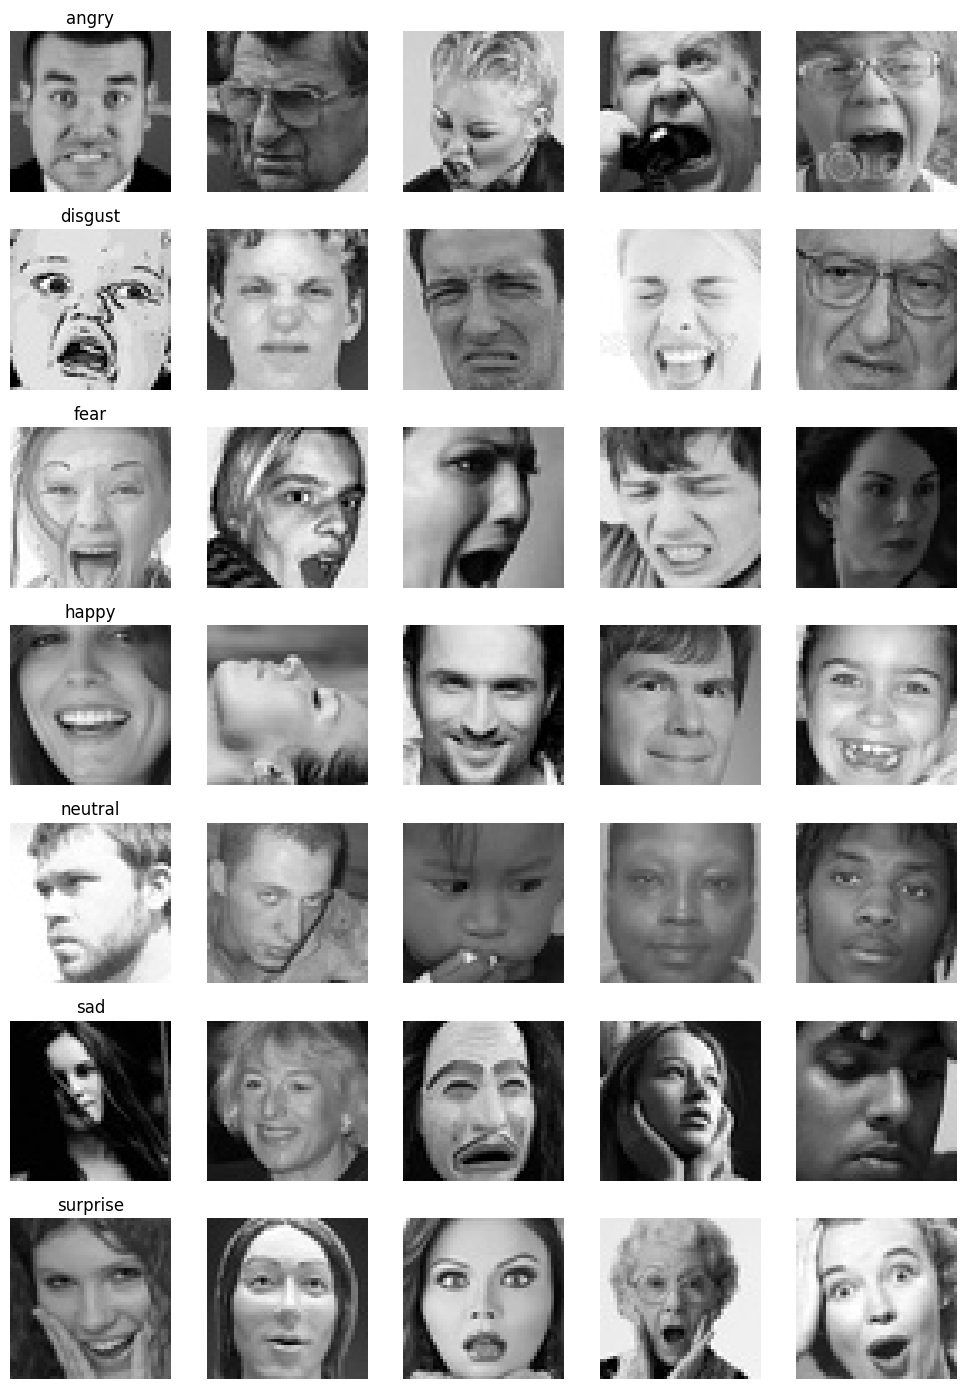

In [10]:
import matplotlib.pyplot as plt
from random import sample
from PIL import Image
from pathlib import Path

train = Path("data")/"train"
classes = [d.name for d in train.iterdir() if d.is_dir()]
n_per = 5
fig, axes = plt.subplots(len(classes), n_per, figsize=(n_per*2, len(classes)*2))
for i, cls in enumerate(sorted(classes)):
    files = list((train/cls).glob("*"))
    files = sample(files, min(n_per, len(files)))
    for j in range(n_per):
        ax = axes[i,j] if len(classes)>1 else axes[j]
        if j < len(files):
            img = Image.open(files[j]).convert("RGB")
            ax.imshow(img)
            ax.set_title(cls if j==0 else "")
        ax.axis("off")
plt.tight_layout()

### Detect exact duplicate files (hash)

In [11]:
import hashlib
from pathlib import Path
hashes = {}
dups = []
for f in (Path("data")/"train").rglob("*"):
    if not f.is_file(): continue
    h = hashlib.md5(f.read_bytes()).hexdigest()
    if h in hashes:
        dups.append((f, hashes[h]))
    else:
        hashes[h] = f
len(dups), dups[:5]

(1236,
 [(WindowsPath('data/train/angry/Training_12775696.jpg'),
   WindowsPath('data/train/angry/Training_11860503.jpg')),
  (WindowsPath('data/train/angry/Training_18699711.jpg'),
   WindowsPath('data/train/angry/Training_16527960.jpg')),
  (WindowsPath('data/train/angry/Training_19321092.jpg'),
   WindowsPath('data/train/angry/Training_1886687.jpg')),
  (WindowsPath('data/train/angry/Training_20374852.jpg'),
   WindowsPath('data/train/angry/Training_17427197.jpg')),
  (WindowsPath('data/train/angry/Training_24299949.jpg'),
   WindowsPath('data/train/angry/Training_14530363.jpg'))])

### Remove the Duplicates

In [13]:
import hashlib
from pathlib import Path

hashes = {}
removed = 0

for f in (Path("data") / "train").rglob("*"):
    if not f.is_file():
        continue
    h = hashlib.md5(f.read_bytes()).hexdigest()
    if h in hashes:
        f.unlink()      # delete the duplicate
        removed += 1
    else:
        hashes[h] = f

print(f"Removed {removed} duplicate files.")
print(f"Training images remaining: {sum(1 for f in (Path('data')/'train').rglob('*') if f.is_file())}")


Removed 1236 duplicate files.
Training images remaining: 27473


### Check for train/test overlap

In [14]:
# Check for train/test overlap
train_hashes = {hashlib.md5(f.read_bytes()).hexdigest() for f in (Path("data")/"train").rglob("*") if f.is_file()}
test_hashes  = {hashlib.md5(f.read_bytes()).hexdigest() for f in (Path("data")/"test").rglob("*") if f.is_file()}

overlap = train_hashes & test_hashes
print(f"Images appearing in both train and test: {len(overlap)}")

Images appearing in both train and test: 531


### Remove the 531 Cross-Split Duplicates from Test

In [15]:
import hashlib
from pathlib import Path

# Build hash set from cleaned training set
train_hashes = {
    hashlib.md5(f.read_bytes()).hexdigest()
    for f in (Path("data") / "train").rglob("*")
    if f.is_file()
}

removed = 0
for f in (Path("data") / "test").rglob("*"):
    if not f.is_file():
        continue
    h = hashlib.md5(f.read_bytes()).hexdigest()
    if h in train_hashes:
        f.unlink()   # remove from test — it exists in train
        removed += 1

print(f"Removed {removed} test images that overlapped with train.")
print(f"Test images remaining: {sum(1 for f in (Path('data')/'test').rglob('*') if f.is_file())}")


Removed 568 test images that overlapped with train.
Test images remaining: 6610


### Confirm no overlap remains

In [16]:
# Confirm no overlap remains
train_hashes = {hashlib.md5(f.read_bytes()).hexdigest() for f in (Path("data")/"train").rglob("*") if f.is_file()}
test_hashes  = {hashlib.md5(f.read_bytes()).hexdigest() for f in (Path("data")/"test").rglob("*") if f.is_file()}
print("Remaining overlap:", len(train_hashes & test_hashes))  # should print 0

Remaining overlap: 0


### Make a CSV manifest (path, split, class) for downstream pipelines

In [17]:
import csv
from pathlib import Path

out = Path("data/manifest.csv")
with open(out, "w", newline="") as fh:
    writer = csv.writer(fh)
    writer.writerow(["split","class","path"])
    for split in ("train","test"):
        base = Path("data")/split
        if not base.exists(): continue
        for cls in sorted([d for d in base.iterdir() if d.is_dir()]):
            for f in (base/cls).glob("*"):
                if f.is_file():
                    writer.writerow([split, cls.name, str(f.resolve())])
print("Manifest saved to", out)

Manifest saved to data\manifest.csv


### Compute class weights (to pass to model.fit)

In [18]:
import numpy as np
from sklearn.utils.class_weight import compute_class_weight
from pathlib import Path

labels = []
for cls in sorted((Path("data")/"train").iterdir()):
    if cls.is_dir():
        n = sum(1 for f in cls.glob("*") if f.is_file())
        labels += [cls.name]*n
classes = np.unique(labels)
cw = compute_class_weight("balanced", classes=classes, y=np.array(labels))
dict(zip(classes, cw))

{np.str_('angry'): np.float64(1.0196711576290687),
 np.str_('disgust'): np.float64(10.30108736407949),
 np.str_('fear'): np.float64(1.0053059133489461),
 np.str_('happy'): np.float64(0.5538687956130801),
 np.str_('neutral'): np.float64(0.8062272567202723),
 np.str_('sad'): np.float64(0.8322125287774143),
 np.str_('surprise'): np.float64(1.4704811861050153)}

###  face detection coverage (OpenCV Haar cascades) — roughly measure how many images contain detectable faces (good for face-based pipelines)

In [19]:
import cv2
from pathlib import Path

detector = cv2.CascadeClassifier(cv2.data.haarcascades + "haarcascade_frontalface_default.xml")
count_with_face = 0
total = 0
for f in (Path("data")/"train").rglob("*"):
    if not f.is_file(): continue
    img = cv2.imread(str(f))
    if img is None: continue
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    faces = detector.detectMultiScale(gray, scaleFactor=1.1, minNeighbors=4)
    total += 1
    if len(faces) > 0:
        count_with_face += 1
print("face coverage:", count_with_face, "/", total)

ModuleNotFoundError: No module named 'cv2'

### We focus on 3 emotions for marketing relevance

In [ ]:
TARGET_EMOTIONS = ["happy", "neutral", "sad"]
IMG_SIZE = (48, 48)  # FER2013 standard image size
 
print("=== IPCV: Emotion Detection Project ===")
print(f"Data directory: {DATA_DIR.resolve()}")
print(f"Target emotions: {TARGET_EMOTIONS}")

## Data Visualization

### 3. CLASS DISTRIBUTION ANALYSIS

In [ ]:
def count_images(base_dir, emotions):
    """Count images per emotion class in a directory."""
    counts = {}
    for emotion in emotions:
        folder = base_dir / emotion
        if folder.exists():
            counts[emotion] = len(list(folder.glob("*.jpg")) + list(folder.glob("*.png")))
        else:
            counts[emotion] = 0
    return counts
 
train_counts = count_images(TRAIN_DIR, TARGET_EMOTIONS)
test_counts  = count_images(TEST_DIR,  TARGET_EMOTIONS)
 
print("\n=== Class Distribution ===")
df_dist = pd.DataFrame({
    "Emotion": TARGET_EMOTIONS,
    "Train":   [train_counts[e] for e in TARGET_EMOTIONS],
    "Test":    [test_counts[e]  for e in TARGET_EMOTIONS],
})
df_dist["Total"] = df_dist["Train"] + df_dist["Test"]
print(df_dist.to_string(index=False))


### Plot class distribution

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
df_dist.set_index("Emotion")[["Train", "Test"]].plot(
    kind="bar", ax=axes[0], color=["#6c5ce7", "#fd79a8"]
)
axes[0].set_title("Class Distribution: Train vs Test")
axes[0].set_xlabel("Emotion")
axes[0].set_ylabel("Number of Images")
axes[0].tick_params(axis="x", rotation=0)
 
df_dist.set_index("Emotion")["Total"].plot(
    kind="pie", ax=axes[1], autopct="%1.1f%%",
    colors=["#55efc4", "#74b9ff", "#ff7675"]
)
axes[1].set_title("Overall Distribution")
axes[1].set_ylabel("")
 
plt.tight_layout()
plt.savefig("../images/01_class_distribution.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: ../images/01_class_distribution.png")


### 4. SAMPLE IMAGE DISPLAY

In [ ]:
import cv2  # pip install opencv-python
 
def load_sample_images(base_dir, emotions, n=5):
    """Load n sample images per emotion class."""
    samples = {}
    for emotion in emotions:
        folder = base_dir / emotion
        if folder.exists():
            files = list(folder.glob("*.jpg"))[:n]
            images = [cv2.imread(str(f), cv2.IMREAD_GRAYSCALE) for f in files]
            samples[emotion] = images
    return samples
 
train_samples = load_sample_images(TRAIN_DIR, TARGET_EMOTIONS, n=5)
 
fig, axes = plt.subplots(len(TARGET_EMOTIONS), 5, figsize=(15, 3 * len(TARGET_EMOTIONS)))
for row, emotion in enumerate(TARGET_EMOTIONS):
    images = train_samples.get(emotion, [])
    for col in range(5):
        ax = axes[row, col]
        if col < len(images) and images[col] is not None:
            ax.imshow(images[col], cmap="gray")
        else:
            ax.axis("off")
        if col == 0:
            ax.set_ylabel(emotion.capitalize(), fontsize=12, fontweight="bold")
        ax.set_xticks([])
        ax.set_yticks([])
 
plt.suptitle("Sample Images per Emotion Class (FER2013 — Train Set)", fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig("../images/01_sample_images.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: ../images/01_sample_images.png")
 

### 5. IMAGE PROPERTY ANALYSIS

In [ ]:
def analyze_image_properties(base_dir, emotions, sample_size=50):
    """Analyze pixel statistics across a sample of images."""
    stats = []
    for emotion in emotions:
        folder = base_dir / emotion
        if not folder.exists():
            continue
        files = list(folder.glob("*.jpg"))[:sample_size]
        for f in files:
            img = cv2.imread(str(f), cv2.IMREAD_GRAYSCALE)
            if img is not None:
                stats.append({
                    "emotion": emotion,
                    "height": img.shape[0],
                    "width": img.shape[1],
                    "mean_pixel": img.mean(),
                    "std_pixel": img.std(),
                    "min_pixel": img.min(),
                    "max_pixel": img.max(),
                })
    return pd.DataFrame(stats)
 
df_stats = analyze_image_properties(TRAIN_DIR, TARGET_EMOTIONS)
 
print("\n=== Image Pixel Statistics by Emotion ===")
print(df_stats.groupby("emotion")[["mean_pixel", "std_pixel"]].describe().round(2))
 
# Pixel intensity distribution
fig, axes = plt.subplots(1, len(TARGET_EMOTIONS), figsize=(15, 4))
colors = {"happy": "#55efc4", "neutral": "#74b9ff", "sad": "#ff7675"}
for i, emotion in enumerate(TARGET_EMOTIONS):
    subset = df_stats[df_stats["emotion"] == emotion]["mean_pixel"]
    axes[i].hist(subset, bins=20, color=colors.get(emotion, "gray"), edgecolor="white")
    axes[i].set_title(f"{emotion.capitalize()}\n(n={len(subset)})")
    axes[i].set_xlabel("Mean Pixel Intensity")
    axes[i].set_ylabel("Frequency")
 
plt.suptitle("Pixel Intensity Distribution per Emotion", fontsize=13)
plt.tight_layout()
plt.savefig("../images/01_pixel_distribution.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: ../images/01_pixel_distribution.png")

### 6. SUMMARY FOR REPORT

In [ ]:
print("\n" + "="*50)
print("SUMMARY — copy into your Part 1 / Part 2 report")
print("="*50)
total_train = sum(train_counts.values())
total_test  = sum(test_counts.values())
print(f"Dataset:       FER2013 (filtered to {len(TARGET_EMOTIONS)} classes)")
print(f"Train images:  {total_train}")
print(f"Test images:   {total_test}")
print(f"Image size:    {IMG_SIZE[0]}x{IMG_SIZE[1]} px, grayscale")
print(f"Classes used:  {', '.join(TARGET_EMOTIONS)}")
print(f"\nClass balance:")
for e in TARGET_EMOTIONS:
    pct = train_counts[e] / total_train * 100 if total_train > 0 else 0
    print(f"  {e:<10} {train_counts[e]:>5} train images ({pct:.1f}%)")
print("\n  Note: FER2013 is known to have ~65-68% human labeling accuracy.")
print("   Document this as a dataset limitation in your report.")


## Phase 2 — Preprocessing & Data Pipeline

This phase bridges the raw image folders and the model. We:
- Resize every image to **48×48**, convert to **grayscale**, and **normalize** using the mean/std computed during EDA
- Restrict the pipeline to the **3 target emotions** (`happy`, `neutral`, `sad`)
- Build a **train / validation / test** input pipeline with `ImageDataGenerator`, carving the validation set out of `train/`
- Recompute **class weights** for just these 3 classes (the earlier weights covered all 7 emotions) to feed into `model.fit`

In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import numpy as np

# Reuse the per-channel stats computed earlier during EDA (grayscale, so channels are equal)
MEAN = 0.5077
STD  = 0.2551

def normalize(img):
    """Scale pixel values to [0,1], then standardize using dataset mean/std (kept in float32)."""
    img = img.astype("float32")
    return ((img / np.float32(255.0)) - np.float32(MEAN)) / np.float32(STD)

BATCH_SIZE = 64
VAL_SPLIT  = 0.2  # 20% of train/ held out for validation

train_datagen = ImageDataGenerator(
    preprocessing_function=normalize,
    validation_split=VAL_SPLIT,
    rotation_range=10,
    zoom_range=0.1,
    horizontal_flip=True
)

test_datagen = ImageDataGenerator(preprocessing_function=normalize)

train_gen = train_datagen.flow_from_directory(
    TRAIN_DIR, target_size=IMG_SIZE, color_mode="grayscale",
    classes=TARGET_EMOTIONS, class_mode="categorical",
    batch_size=BATCH_SIZE, subset="training", shuffle=True, seed=42
)

val_gen = train_datagen.flow_from_directory(
    TRAIN_DIR, target_size=IMG_SIZE, color_mode="grayscale",
    classes=TARGET_EMOTIONS, class_mode="categorical",
    batch_size=BATCH_SIZE, subset="validation", shuffle=False, seed=42
)

test_gen = test_datagen.flow_from_directory(
    TEST_DIR, target_size=IMG_SIZE, color_mode="grayscale",
    classes=TARGET_EMOTIONS, class_mode="categorical",
    batch_size=BATCH_SIZE, shuffle=False
)

print(f"Train: {train_gen.samples} images, {len(train_gen)} batches")
print(f"Val:   {val_gen.samples} images, {len(val_gen)} batches")
print(f"Test:  {test_gen.samples} images, {len(test_gen)} batches")
print(f"Class indices: {train_gen.class_indices}")

In [ ]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

# Class weights — recomputed for the 3 target emotions only
y_train = train_gen.classes
class_indices = train_gen.class_indices

weights = compute_class_weight("balanced", classes=np.unique(y_train), y=y_train)
class_weight_dict = dict(zip(np.unique(y_train), weights))

print("Class weights (passed to model.fit):")
for label, idx in class_indices.items():
    print(f"  {label:8s} (index {idx}): weight = {class_weight_dict[idx]:.3f}")

# Sanity-check one batch before building the model
images, labels = next(train_gen)
print("\nBatch shape:", images.shape)
print("Labels shape:", labels.shape)
print("Pixel value range:", round(images.min(), 2), "to", round(images.max(), 2))
print("Sample one-hot label:", labels[0], "->", list(class_indices.keys())[labels[0].argmax()])

## Phase 3 — Data Augmentation

Augmentation is **already folded into the `train_datagen` pipeline built in Phase 2** — that's the standard way to apply it with `ImageDataGenerator` (it's applied on-the-fly to each training batch, never touching `val_gen`/`test_gen`).

The augmentations in use:
- `rotation_range=10` — small random rotations (±10°)
- `zoom_range=0.1` — slight random zoom in/out
- `horizontal_flip=True` — random horizontal mirroring (a flipped face is still a face)

Since the 3-class imbalance is mild (confirmed by the class weights above), this step is mainly about **robustness** — helping the model generalize to slightly different framing/lighting/orientation rather than correcting skew. Let's visualize what the augmented images actually look like.

In [ ]:
import matplotlib.pyplot as plt
from pathlib import Path

Path("../images").mkdir(parents=True, exist_ok=True)

# Plain generator with NO normalization — purely for visualizing raw pixel values
preview_datagen = ImageDataGenerator()
preview_gen = preview_datagen.flow_from_directory(
    TRAIN_DIR, target_size=IMG_SIZE, color_mode="grayscale",
    classes=TARGET_EMOTIONS, class_mode="categorical",
    batch_size=1, shuffle=True, seed=7
)
raw_img, _ = next(preview_gen)

fig, axes = plt.subplots(1, 6, figsize=(18, 3))
axes[0].imshow(raw_img[0].squeeze(), cmap="gray", vmin=0, vmax=255)
axes[0].set_title("Original")
axes[0].axis("off")

for i in range(1, 6):
    augmented = train_datagen.random_transform(raw_img[0])
    axes[i].imshow(augmented.squeeze(), cmap="gray", vmin=0, vmax=255)
    axes[i].set_title(f"Augmented #{i}")
    axes[i].axis("off")

plt.suptitle("Data Augmentation Examples — Rotation / Zoom / Horizontal Flip", fontsize=13)
plt.tight_layout()
plt.savefig("../images/03_augmentation_examples.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: ../images/03_augmentation_examples.png")

## Phase 4 — Model Building

**Decision point — custom CNN vs. transfer learning:**
We build a **custom CNN from scratch** rather than using transfer learning. FER2013 images are **48×48 grayscale**, while most pretrained networks (VGG, ResNet, MobileNet, etc.) expect **224×224 RGB** input — adapting them would mean upscaling tiny grayscale images to 224×224 and tiling the single channel into 3, which adds complexity without a clear benefit on a dataset this different from ImageNet. A compact custom CNN is the cleaner, more defensible choice here, and is small enough to train quickly on CPU.

**Architecture:** three `Conv → BatchNorm → Conv → BatchNorm → MaxPool → Dropout` blocks with increasing filter counts (32 → 64 → 128), followed by a dense classifier head with dropout for regularization and a 3-unit softmax output (`happy`, `neutral`, `sad`).

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Input, Conv2D, BatchNormalization, MaxPooling2D, Dropout, Flatten, Dense
)

NUM_CLASSES = len(TARGET_EMOTIONS)

model = Sequential([
    Input(shape=(IMG_SIZE[0], IMG_SIZE[1], 1)),

    # Block 1
    Conv2D(32, (3, 3), activation="relu", padding="same"),
    BatchNormalization(),
    Conv2D(32, (3, 3), activation="relu", padding="same"),
    BatchNormalization(),
    MaxPooling2D(pool_size=(2, 2)),
    Dropout(0.25),

    # Block 2
    Conv2D(64, (3, 3), activation="relu", padding="same"),
    BatchNormalization(),
    Conv2D(64, (3, 3), activation="relu", padding="same"),
    BatchNormalization(),
    MaxPooling2D(pool_size=(2, 2)),
    Dropout(0.25),

    # Block 3
    Conv2D(128, (3, 3), activation="relu", padding="same"),
    BatchNormalization(),
    Conv2D(128, (3, 3), activation="relu", padding="same"),
    BatchNormalization(),
    MaxPooling2D(pool_size=(2, 2)),
    Dropout(0.3),

    # Classifier head
    Flatten(),
    Dense(256, activation="relu"),
    BatchNormalization(),
    Dropout(0.5),
    Dense(NUM_CLASSES, activation="softmax")
])

model.summary()

## Phase 5 — Training

Compile with **Adam** and **categorical crossentropy** (standard for multi-class softmax classification), attach callbacks for robust training, then fit using the **class weights** computed in Phase 2 to account for the mild class imbalance.

Callbacks used:
- **EarlyStopping** — stops training once validation loss stops improving, restoring the best weights (prevents overfitting / wasted epochs)
- **ModelCheckpoint** — saves the best-performing model to disk during training
- **ReduceLROnPlateau** — lowers the learning rate when validation loss plateaus, helping the model fine-tune in later epochs

### Compile the model & define callbacks

In [ ]:
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from pathlib import Path

model.compile(
    optimizer=Adam(learning_rate=1e-3),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

Path("../models").mkdir(parents=True, exist_ok=True)

callbacks = [
    EarlyStopping(monitor="val_loss", patience=8, restore_best_weights=True, verbose=1),
    ModelCheckpoint("../models/best_emotion_model.keras", monitor="val_accuracy",
                    save_best_only=True, verbose=1),
    ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=3, min_lr=1e-6, verbose=1),
]

### Train the model

This will take a while on CPU — `EarlyStopping` will cut training short once validation loss stops improving, so you won't necessarily run all 50 epochs.

In [ ]:
EPOCHS = 50

history = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=EPOCHS,
    class_weight=class_weight_dict,
    callbacks=callbacks,
    verbose=1
)

### Save the trained model

In [ ]:
model.save("../models/final_emotion_model.keras")
print("Model saved to ../models/final_emotion_model.keras")
print("Best checkpoint saved to ../models/best_emotion_model.keras")

## Phase 6 — Evaluation

With training complete, we evaluate on the **held-out test set** (which has zero overlap with train, confirmed earlier) using the metrics that will form the evidence base for your write-up:
- Accuracy / loss curves — show whether the model converged and whether it overfit
- Confusion matrix — shows exactly which emotions get confused with each other
- Classification report — precision / recall / F1 per class
- Error analysis — a visual look at *which* images the model gets wrong, and why

In [ ]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history.history["accuracy"], label="Train")
axes[0].plot(history.history["val_accuracy"], label="Validation")
axes[0].set_title("Model Accuracy")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Accuracy")
axes[0].legend()

axes[1].plot(history.history["loss"], label="Train")
axes[1].plot(history.history["val_loss"], label="Validation")
axes[1].set_title("Model Loss")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Loss")
axes[1].legend()

plt.suptitle("Training History", fontsize=13)
plt.tight_layout()
plt.savefig("../images/06_training_curves.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: ../images/06_training_curves.png")

### Confusion matrix

In [ ]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

test_gen.reset()
y_true = test_gen.classes
y_pred_probs = model.predict(test_gen, verbose=1)
y_pred = np.argmax(y_pred_probs, axis=1)

labels = list(test_gen.class_indices.keys())
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=labels, yticklabels=labels)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix — Test Set")
plt.tight_layout()
plt.savefig("../images/06_confusion_matrix.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: ../images/06_confusion_matrix.png")

### Classification report (precision / recall / F1 per class)

In [ ]:
from sklearn.metrics import classification_report

print("=== Classification Report — Test Set ===")
print(classification_report(y_true, y_pred, target_names=labels, digits=3))

### Error analysis — misclassified samples

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

misclassified = np.where(y_pred != y_true)[0]
print(f"Misclassified: {len(misclassified)} / {len(y_true)} test images "
      f"({len(misclassified) / len(y_true) * 100:.1f}%)")

sample_idx = np.random.choice(misclassified, size=min(10, len(misclassified)), replace=False)
test_filepaths = np.array(test_gen.filepaths)

fig, axes = plt.subplots(2, 5, figsize=(15, 6))
for ax, idx in zip(axes.flatten(), sample_idx):
    img = plt.imread(test_filepaths[idx])
    ax.imshow(img, cmap="gray")
    ax.set_title(f"True: {labels[y_true[idx]]}\nPred: {labels[y_pred[idx]]}", fontsize=10)
    ax.axis("off")

plt.suptitle("Error Analysis — Misclassified Test Images", fontsize=13)
plt.tight_layout()
plt.savefig("../images/06_error_analysis.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: ../images/06_error_analysis.png")

## Phase 7 — Face Detection + Emotion Inference Pipeline

This is where the **"social media images"** half of the project comes in. FER2013 gives us pre-cropped 48×48 grayscale faces, but a real social media photo is full-color, full-scene, and at an arbitrary resolution. So the inference pipeline has to do everything the dataset already did for us:

**load image → detect face (Haar cascade) → crop → resize to 48×48 → grayscale → normalize → predict emotion**

**Decision point — where do the demo images come from?**
You'll need a small handful (5–10) of real social-media-style images with clearly visible faces. Save them into a folder named `demo_images/` placed **next to** your project folder (i.e. one level up from this notebook — the cell below creates it for you at `../demo_images/`). Good sources: your own photos, royalty-free face photo sites, or a few sample images saved from social posts (for educational use only).

In [ ]:
import cv2
import numpy as np
from pathlib import Path

face_detector = cv2.CascadeClassifier(cv2.data.haarcascades + "haarcascade_frontalface_default.xml")
EMOTION_LABELS = list(train_gen.class_indices.keys())  # ['happy', 'neutral', 'sad']

def detect_and_predict_emotions(image_path, model, detector=face_detector,
                                img_size=IMG_SIZE, mean=MEAN, std=STD):
    """
    Full social-media inference pipeline:
    load -> detect faces -> crop -> resize -> grayscale -> normalize -> predict emotion.

    Returns the original BGR image plus a list of (box, predicted_label, confidence)
    — one entry per detected face.
    """
    img = cv2.imread(str(image_path))
    if img is None:
        raise FileNotFoundError(f"Could not read image: {image_path}")

    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    faces = detector.detectMultiScale(gray, scaleFactor=1.1, minNeighbors=5, minSize=(40, 40))

    results = []
    for (x, y, w, h) in faces:
        face = gray[y:y + h, x:x + w]
        face = cv2.resize(face, img_size).astype("float32")
        face = (face / 255.0 - mean) / std
        face = np.expand_dims(face, axis=(0, -1))  # -> (1, 48, 48, 1)

        probs = model.predict(face, verbose=0)[0]
        pred_idx = int(np.argmax(probs))
        results.append(((x, y, w, h), EMOTION_LABELS[pred_idx], float(probs[pred_idx])))

    return img, results

### Run the pipeline on demo images

Drop a handful of social media images (with visible faces) into `../demo_images/`, then run the cell below — it will detect each face, predict its emotion, and draw the result directly on the image.

In [ ]:
import matplotlib.pyplot as plt

DEMO_DIR = Path("../demo_images")
DEMO_DIR.mkdir(parents=True, exist_ok=True)

demo_files = [f for f in DEMO_DIR.glob("*") if f.suffix.lower() in (".jpg", ".jpeg", ".png")]

if not demo_files:
    print(f"No demo images found in {DEMO_DIR.resolve()}")
    print("Add a few social media images with visible faces to that folder, then re-run this cell.")
else:
    fig, axes = plt.subplots(1, len(demo_files), figsize=(5 * len(demo_files), 5))
    if len(demo_files) == 1:
        axes = [axes]

    for ax, f in zip(axes, demo_files):
        img, results = detect_and_predict_emotions(f, model)
        img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        for (x, y, w, h), label, conf in results:
            cv2.rectangle(img_rgb, (x, y), (x + w, y + h), (0, 255, 0), 2)
            cv2.putText(img_rgb, f"{label} ({conf:.0%})", (x, max(y - 10, 0)),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 255, 0), 2)

        ax.imshow(img_rgb)
        ax.set_title(f.name)
        ax.axis("off")

    plt.tight_layout()
    plt.savefig("../images/07_inference_demo.png", dpi=150, bbox_inches="tight")
    plt.show()
    print("Saved: ../images/07_inference_demo.png")

## Phase 8 — Marketing Insights

This closes the loop on the research question: *"How can image processing techniques be used to detect emotional expressions in social media images, and how can this improve marketing analytics?"*

We run the full pipeline over the demo batch, aggregate every detected face's predicted emotion, and translate the resulting distribution into a marketing-relevant takeaway.

In [ ]:
import pandas as pd

all_predictions = []
for f in demo_files:
    _, results = detect_and_predict_emotions(f, model)
    for (_, label, conf) in results:
        all_predictions.append({"image": f.name, "emotion": label, "confidence": round(conf, 3)})

df_insights = pd.DataFrame(all_predictions)
print(f"Total faces analyzed: {len(df_insights)}")
df_insights

In [ ]:
import matplotlib.pyplot as plt

emotion_counts = df_insights["emotion"].value_counts().reindex(TARGET_EMOTIONS, fill_value=0)

fig, ax = plt.subplots(figsize=(7, 5))
emotion_counts.plot(kind="bar", color=["#55efc4", "#74b9ff", "#ff7675"], ax=ax)
ax.set_title("Emotional Breakdown of Analyzed Social Media Images")
ax.set_xlabel("Emotion")
ax.set_ylabel("Number of Faces Detected")
ax.tick_params(axis="x", rotation=0)
plt.tight_layout()
plt.savefig("../images/08_marketing_insights.png", dpi=150, bbox_inches="tight")
plt.show()

total = emotion_counts.sum()
print("\n" + "=" * 50)
print("MARKETING INSIGHTS — connecting back to the research question")
print("=" * 50)
for emotion, count in emotion_counts.items():
    pct = (count / total * 100) if total > 0 else 0
    print(f"  {emotion:<10} {count:>3} faces ({pct:.1f}%)")

if total > 0:
    dominant = emotion_counts.idxmax()
    print(f"\nDominant emotion detected: '{dominant}'")
    print("Marketing takeaway: content that elicits this emotion appears to resonate")
    print("most with this audience sample. Campaigns could lean into that emotional")
    print("register, while content skewing toward under-represented emotions may need")
    print("re-evaluation or A/B testing to confirm real-world engagement impact.")
else:
    print("\nNo faces detected in the demo batch — add images with clearer/larger faces.")